Exploratory Data Analysis (EDA) - Convolutional Neural Network for Automatic Handwritten Digit Recognition

Objective
- To analyze and understand the dataset before building the CNN model.

1. Import Required Libraries

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

print("import success")

import success


2. Load Dataset

In [15]:
train_data = pd.read_csv("D:\IBM PROJECT\mnist_train.csv")
test_data = pd.read_csv("D:\IBM PROJECT\mnist_test.csv")

# train_data = pd.read_csv("mnist_train.csv")
# test_data = pd.read_csv("mnist_test.csv")

<>:1: SyntaxWarning: invalid escape sequence '\I'
<>:2: SyntaxWarning: invalid escape sequence '\I'
<>:1: SyntaxWarning: invalid escape sequence '\I'
<>:2: SyntaxWarning: invalid escape sequence '\I'
C:\Users\Aishwarya\AppData\Local\Temp\ipykernel_30352\4260334190.py:1: SyntaxWarning: invalid escape sequence '\I'
  train_data = pd.read_csv("D:\IBM PROJECT\mnist_train.csv")
C:\Users\Aishwarya\AppData\Local\Temp\ipykernel_30352\4260334190.py:2: SyntaxWarning: invalid escape sequence '\I'
  test_data = pd.read_csv("D:\IBM PROJECT\mnist_test.csv")


3. Basic Data Understanding

In [17]:
print("Train Shape:", train_data.shape)
print("Test Shape:", test_data.shape)

print("train data: " , train_data.head())
print("test data: " , test_data.head())

Train Shape: (59999, 785)
Test Shape: (9999, 785)
train data:     5  0  0.1  0.2  0.3  0.4  0.5  0.6  0.7  0.8  ...  0.608  0.609  0.610  \
0  0  0    0    0    0    0    0    0    0    0  ...      0      0      0   
1  4  0    0    0    0    0    0    0    0    0  ...      0      0      0   
2  1  0    0    0    0    0    0    0    0    0  ...      0      0      0   
3  9  0    0    0    0    0    0    0    0    0  ...      0      0      0   
4  2  0    0    0    0    0    0    0    0    0  ...      0      0      0   

   0.611  0.612  0.613  0.614  0.615  0.616  0.617  
0      0      0      0      0      0      0      0  
1      0      0      0      0      0      0      0  
2      0      0      0      0      0      0      0  
3      0      0      0      0      0      0      0  
4      0      0      0      0      0      0      0  

[5 rows x 785 columns]
test data:     7  0  0.1  0.2  0.3  0.4  0.5  0.6  0.7  0.8  ...  0.658  0.659  0.660  \
0  2  0    0    0    0    0    0    0    0 

In [20]:
train_data.iloc[:,0].nunique()

10

Dataset contains 10 classes (digits 0–9)

4. Data Quality Check

In [24]:
train_data.isnull().sum()

5        0
0        0
0.1      0
0.2      0
0.3      0
        ..
0.613    0
0.614    0
0.615    0
0.616    0
0.617    0
Length: 785, dtype: int64

Missing Values Observation
- No missing values are present in the dataset, so no data cleaning is required.

In [27]:
train_data.iloc[:,1:].describe()

,0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,...,0.608,0.609,0.610,0.611,0.612,0.613,0.614,0.615,0.616,0.617
count,59999.0,59999.0,59999.0,59999.0,59999.0,59999.0,59999.0,59999.0,59999.0,59999.0,...,59999.000000,59999.000000,59999.000000,59999.000000,59999.000000,59999.000000,59999.0,59999.0,59999.0,59999.0
mean,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.200437,0.088868,0.045634,0.019284,0.015117,0.002000,0.0,0.0,0.0,0.0
std,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,6.042522,3.956222,2.839868,1.686784,1.678297,0.346603,0.0,0.0,0.0,0.0
min,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0
25%,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0
50%,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0
75%,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0
max,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,254.000000,254.000000,253.000000,253.000000,254.000000,62.000000,0.0,0.0,0.0,0.0


Pixel Value Insight
- Pixel values range from 0–255
- Data represents grayscale intensity

In [30]:
train_data.dtypes

5        int64
0        int64
0.1      int64
0.2      int64
0.3      int64
         ...  
0.613    int64
0.614    int64
0.615    int64
0.616    int64
0.617    int64
Length: 785, dtype: object

Data Type Insight
- All columns are numeric
- No incorrect data types present

5. Label Distribution

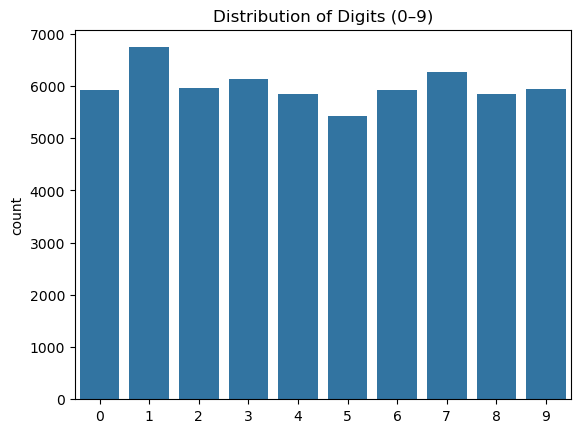

In [33]:
X_train = train_data.iloc[:, 1:].values
y_train = train_data.iloc[:, 0].values

X_test = test_data.iloc[:, 1:].values
y_test = test_data.iloc[:, 0].values


sns.countplot(x=y_train)
plt.title("Distribution of Digits (0–9)")
plt.show()

Dataset is balanced across all digits

6. Sample images

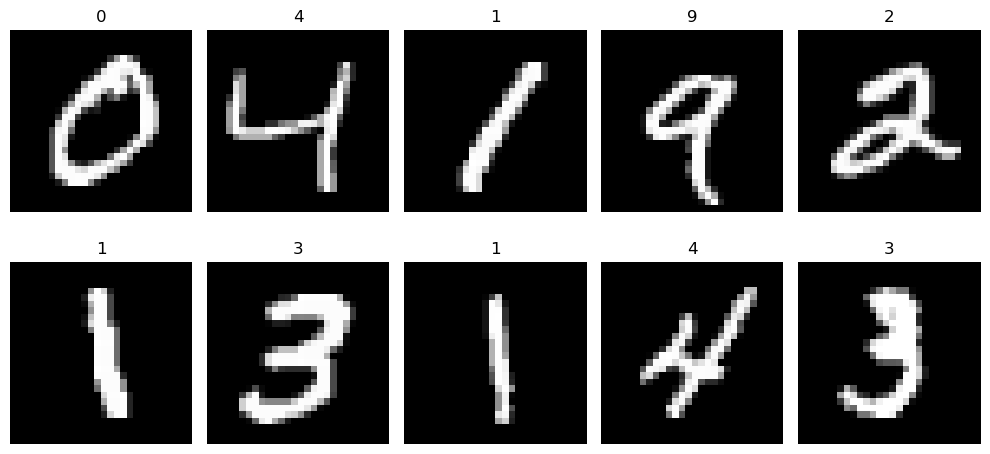

In [37]:
plt.figure(figsize=(10,5))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(X_train[i].reshape(28,28), cmap='gray')
    plt.title(f"{y_train[i]}")
    plt.axis('off')

plt.tight_layout()
plt.show()

- Images are clearly visible and correctly labeled
- Digits are centered and consistent

7. Pixel Intensity Histogram

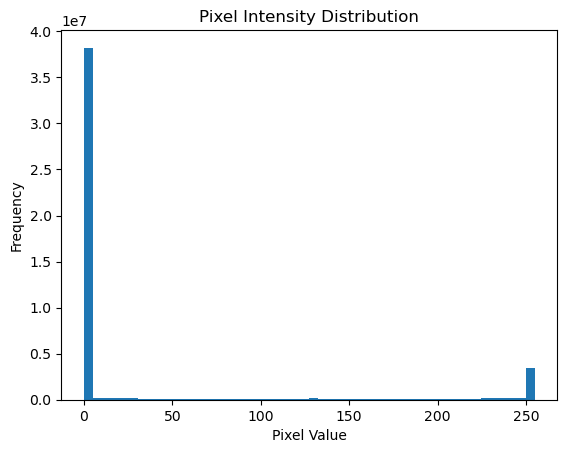

In [40]:
plt.hist(X_train.flatten(), bins=50)
plt.title("Pixel Intensity Distribution")
plt.xlabel("Pixel Value")
plt.ylabel("Frequency")
plt.show()

- Most pixels have low intensity (background)
- Only a small portion represents the digit

8. Mean Image

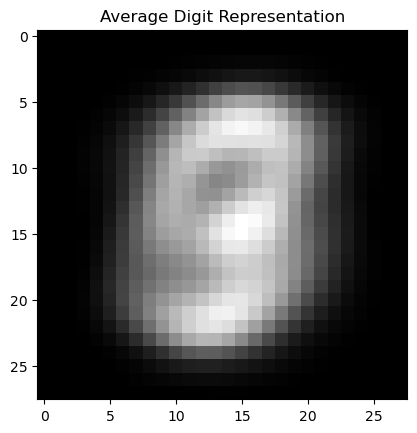

In [43]:
mean_image = np.mean(train_data.iloc[:,1:].values, axis=0).reshape(28,28)

plt.imshow(mean_image, cmap='gray')
plt.title("Average Digit Representation")
plt.show()

Mean Image Insight
- The average image shows the general structure of digits, confirming that digits are centered and follow a consistent pattern.

Insights

- Dataset is balanced across all digits (0–9)
- Images are 28×28 grayscale
- Pixel values range from 0 to 255
- No missing values found
- Most pixels are background (low intensity)
- Digits are centered and consistent